# **Exercise for Unit 5**

**Name:** Myrrhea Belle B. Junsay <br>
**Date:** April 10, 2026 <br>
**Year and Section:** BSCS3A -AI <br>

In [38]:
"""
Train Skip-gram with Negative Sampling on a Wikipedia article,
then evaluate the embedding model with intrinsic tests and custom test sets.

Requirements:
! pip install requests beautifulsoup4 nltk gensim scikit-learn scipy

Optional:
    python -m nltk.downloader punkt stopwords
"""

import re
import math
import json
import random
from collections import Counter
from typing import List, Tuple, Dict

import requests
from bs4 import BeautifulSoup
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def ensure_nltk():
    resources = ["punkt", "punkt_tab"]
    for r in resources:
        try:
            nltk.data.find(f"tokenizers/{r}")
        except LookupError:
            nltk.download(r)


1. **(10 points) Use a Wikipedia article as your dataset**

In [39]:
# Paste the Wikipedia link you want to use here.
# The article should be reasonably long (at least a few thousand words) for good results.
WIKI_URL = "https://en.wikipedia.org/wiki/Superman"
RANDOM_SEED = 42

def fetch_wikipedia_article(url: str) -> str:
    headers = {
        "User-Agent": "Mozilla/5.0 (compatible; SGNS-Superman-Training/1.0)"
    }
    resp = requests.get(url, headers=headers, timeout=30)
    resp.raise_for_status()

    # Extract main content text from the Wikipedia page
    soup = BeautifulSoup(resp.text, "html.parser")

    content_div = soup.find("div", {"id": "mw-content-text"})
    if content_div is None:
        raise ValueError("Could not find Wikipedia article content.")

    paragraphs = content_div.find_all(["p", "li"])
    text_blocks = []

    for p in paragraphs:
        txt = p.get_text(" ", strip=True)
        if txt:
            text_blocks.append(txt)

    text = "\n".join(text_blocks)

    text = re.sub(r"\[[0-9]+\]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

raw_text = fetch_wikipedia_article(WIKI_URL)
print(f"Fetched {len(raw_text.split())} words from {WIKI_URL}")

Fetched 27743 words from https://en.wikipedia.org/wiki/Superman


2. **Preprocess the text coming from the selected corpus.**

In [40]:
def preprocess_text(text: str) -> List[List[str]]:
    sentences = sent_tokenize(text)

    processed = []
    for sent in sentences:
        sent = sent.lower()
        sent = re.sub(r"[^a-z0-9\-\s]", " ", sent)
        sent = re.sub(r"\s+", " ", sent).strip()
        if not sent:
            continue

        tokens = word_tokenize(sent)

        cleaned = []
        for tok in tokens:
            tok = tok.strip("-")
            if not tok:
                continue
            if tok.isdigit():
                continue
            if len(tok) < 2:
                continue
            cleaned.append(tok)

        if len(cleaned) >= 3:
            processed.append(cleaned)

    return processed

def corpus_stats(sentences: List[List[str]]) -> Dict[str, int]:
    flat = [w for s in sentences for w in s]
    vocab = set(flat)
    return {
        "num_sentences": len(sentences),
        "num_tokens": len(flat),
        "vocab_size": len(vocab),
    }

sentences = preprocess_text(raw_text)
stats = corpus_stats(sentences)
print("\n=== Corpus Stats ===")
for k, v in stats.items():
    print(f"{k}: {v}")


=== Corpus Stats ===
num_sentences: 1159
num_tokens: 23109
vocab_size: 4888


3. **(10 points) Train a Skip-gram with Negative Sampling model.**

In [ ]:
def train_sgns(sentences: List[List[str]]) -> Word2Vec:
    model = Word2Vec(
        sentences=sentences,
        vector_size=100, 
        window=5,
        min_count=1,
        workers=4,
        sg=1,        
        negative=10,  
        epochs=200,
        sample=1e-3,
        alpha=0.025,
        min_alpha=0.0007,
        seed=RANDOM_SEED,
    )
    return model


4. **(10 points) Evaluate the embeddings using a small test set.**

In [ ]:
def has_word(model: Word2Vec, word: str) -> bool:
    return word in model.wv.key_to_index

def cosine(model: Word2Vec, w1: str, w2: str) -> float:
    v1 = model.wv[w1].reshape(1, -1)
    v2 = model.wv[w2].reshape(1, -1)
    return float(cosine_similarity(v1, v2)[0][0])


def evaluate_relatedness(model: Word2Vec, test_pairs: List[Tuple[str, str, float]]):
    gold = []
    pred = []
    covered = []

    for w1, w2, score in test_pairs:
        if has_word(model, w1) and has_word(model, w2):
            sim = cosine(model, w1, w2)
            gold.append(score)
            pred.append(sim)
            covered.append((w1, w2, score, sim))

    return {
        "covered_items": covered,
        "coverage": len(covered),
        "total": len(test_pairs),
    }


def evaluate_analogies(model: Word2Vec, analogies: List[Tuple[str, str, str, str]]):
    """
    Analogy format: a:b :: c:d
    Checks whether most_similar(positive=[b,c], negative=[a]) returns d.
    """
    covered = 0
    correct = 0
    details = []

    for a, b, c, d in analogies:
        if all(has_word(model, w) for w in [a, b, c, d]):
            covered += 1
            try:
                preds = model.wv.most_similar(positive=[b, c], negative=[a], topn=5)
                predicted_words = [w for w, _ in preds]
                hit = d in predicted_words
                correct += int(hit)
                details.append({
                    "analogy": f"{a}:{b}::{c}:?",
                    "expected": d,
                    "predictions": predicted_words,
                    "correct_in_top5": hit
                })
            except KeyError:
                pass

    accuracy = correct / covered if covered else float("nan")
    return {
        "coverage": covered,
        "total": len(analogies),
        "accuracy_top5": accuracy,
        "details": details
    }

def main():
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)
    ensure_nltk()

    print("Downloading Wikipedia article...")
    raw_text = fetch_wikipedia_article(WIKI_URL)

    print("Preprocessing text...")
    sentences = preprocess_text(raw_text)
    stats = corpus_stats(sentences)

    print("\n=== Corpus Stats ===")
    for k, v in stats.items():
        print(f"{k}: {v}")

    print("\nTraining Skip-gram with Negative Sampling...")
    model = train_sgns(sentences)

    print("\nVocabulary size learned:", len(model.wv))

    # Domain-specific relatedness test set
    # Higher score means should be more semantically related
    relatedness_test = [
        ("superman", "kent", 0.95),
        ("clark", "kent", 0.98),
        ("metropolis", "city", 0.85),
        ("krypton", "planet", 0.90),
        ("lois", "lane", 0.95),
        ("hero", "villain", 0.70),
    ]

    rel_results = evaluate_relatedness(model, relatedness_test)

    print("\n=== Relatedness Test Set ===")
    print(f"Coverage: {rel_results['coverage']}/{rel_results['total']}")
    for w1, w2, gold, pred in rel_results["covered_items"]:
        print(f"{w1:10s} - {w2:10s} | gold={gold:.2f} pred={pred:.4f}")

    # Small analogy-style test set
    # These are intentionally tiny and corpus-dependent because a single article is a small dataset.
    # Change this based on what you find in the article and what words are present in the model.
    analogy_test = [
        ("clark", "kent", "lois", "lane"),
        ("man", "clark", "woman", "lois"),
        ("earth", "metropolis", "krypton", "argo"),
    ]

    analogy_results = evaluate_analogies(model, analogy_test)

    print("\n=== Analogy Test Set ===")
    print(f"Coverage: {analogy_results['coverage']}/{analogy_results['total']}")
    print(f"Top-5 accuracy: {analogy_results['accuracy_top5']}")
    for item in analogy_results["details"]:
        print(json.dumps(item, ensure_ascii=False))

    # Example direct similarity checks
    print("\n=== Direct Similarity Checks ===")
    # Change these pairs based on what you expect to be related/unrelated in the article and what words are in the model.
    check_pairs = [
        ("superman", "clark"),
        ("superman", "kent"),
        ("hero", "villain"),
        ("superman", "bread"),
    ]
    for w1, w2 in check_pairs:
        if has_word(model, w1) and has_word(model, w2):
            print(f"{w1:10s} <-> {w2:10s}: {cosine(model, w1, w2):.4f}")
        else:
            print(f"{w1:10s} <-> {w2:10s}: OOV")

    # Save model
    model.save("exercise_5_skipgram_sgns.model")
    print("\nSaved model to: exercise_5_skipgram_sgns.model")

    print("\nDone.")

main()

Preprocessing text...

=== Corpus Stats ===
num_sentences: 1159
num_tokens: 23109
vocab_size: 4888

Training Skip-gram with Negative Sampling...

Vocabulary size learned: 4888

=== Relatedness Test Set ===
Coverage: 6/6
superman   - kent       | gold=0.95 pred=0.2526
clark      - kent       | gold=0.98 pred=0.6780
metropolis - city       | gold=0.85 pred=0.5363
krypton    - planet     | gold=0.90 pred=0.5163
lois       - lane       | gold=0.95 pred=0.6771
hero       - villain    | gold=0.70 pred=0.4666

=== Analogy Test Set ===
Coverage: 2/3
Top-5 accuracy: 0.5
{"analogy": "clark:kent::lois:?", "expected": "lane", "predictions": ["lane", "lana", "ariella", "lar", "alura"], "correct_in_top5": true}
{"analogy": "man:clark::woman:?", "expected": "lois", "predictions": ["wonder", "kent", "dealt", "trinity", "marand"], "correct_in_top5": false}

=== Direct Similarity Checks ===
superman   <-> clark     : 0.2443
superman   <-> kent      : 0.2526
hero       <-> villain   : 0.4666
superman   <

5. **(10 points) Report nearest neighbors, similarity scores, and test-set performance.**

In [43]:
def print_top_neighbors(model: Word2Vec, words: List[str], topn: int = 8):
    print("\n=== Nearest Neighbors ===")
    for word in words:
        if has_word(model, word):
            neighbors = model.wv.most_similar(word, topn=topn)
            print(f"\n{word}:")
            for neigh, score in neighbors:
                print(f"  {neigh:20s} {score:.4f}")
        else:
            print(f"\n{word}: [OOV]")

probe_words = [
    "superman", "clark", "kent", "metropolis", "hero", "planet"
]

model = Word2Vec.load("exercise_5_skipgram_sgns.model")

print_top_neighbors(model, probe_words, topn=8)


=== Nearest Neighbors ===

superman:
  peace                0.3720
  in                   0.3575
  trinity              0.3565
  enter                0.3562
  foes                 0.3490
  spawned              0.3480
  predator             0.3463
  versus               0.3458

clark:
  kent                 0.6780
  marand               0.5745
  patricia             0.5613
  actress              0.5530
  deflect              0.5416
  suspicion            0.5402
  performed            0.5335
  admits               0.5153

kent:
  worcesterm           0.6839
  clark                0.6780
  jeet                 0.6512
  heer                 0.6497
  chief                0.6388
  actress              0.6375
  patricia             0.6363
  marand               0.6325

metropolis:
  symphony             0.6908
  illinois             0.6797
  bird                 0.6679
  gene                 0.6635
  mailbag              0.6633
  skyscrapers          0.6618
  scout                0.6318
  jo

In [46]:
print("\n--- Retraining Model with Window Size 10 ---")

def train_sgns_window10(sentences: List[List[str]]) -> Word2Vec:
    model = Word2Vec(
        sentences=sentences,
        vector_size=100,
        window=10,  # Changed window size to 10
        min_count=1,
        workers=4,
        sg=1,
        negative=10,
        epochs=200,
        sample=1e-3,
        alpha=0.025,
        min_alpha=0.0007,
        seed=RANDOM_SEED,
    )
    return model

# Ensure NLTK resources are available and text is preprocessed
ensure_nltk()
if 'raw_text' not in locals():
    raw_text = fetch_wikipedia_article(WIKI_URL)
if 'sentences' not in locals():
    sentences = preprocess_text(raw_text)

print("\nTraining new Skip-gram with Negative Sampling model (window=10)...")
model_new = train_sgns_window10(sentences)
print("Vocabulary size learned (new model):", len(model_new.wv))

# Save the new model
model_new.save("exercise_5_skipgram_sgns_window10.model")
print("Saved new model to: exercise_5_skipgram_sgns_window10.model")

print("\n--- Evaluation for NEW Model (Window=10) ---")
rel_results_new = evaluate_relatedness(model_new, relatedness_test)
print("\n=== Relatedness Test Set (NEW) ===")
print(f"Coverage: {rel_results_new['coverage']}/{rel_results_new['total']}")
for w1, w2, gold, pred in rel_results_new["covered_items"]:
    print(f"{w1:10s} - {w2:10s} | gold={gold:.2f} pred={pred:.4f}")

analogy_results_new = evaluate_analogies(model_new, analogy_test)
print("\n=== Analogy Test Set (NEW) ===")
print(f"Coverage: {analogy_results_new['coverage']}/{analogy_results_new['total']}")
print(f"Top-5 accuracy: {analogy_results_new['accuracy_top5']:.4f}")

print("\n=== Direct Similarity Checks (NEW) ===")
for w1, w2 in check_pairs:
    if has_word(model_new, w1) and has_word(model_new, w2):
        print(f"{w1:10s} <-> {w2:10s}: {cosine(model_new, w1, w2):.4f}")
    else:
        print(f"{w1:10s} <-> {w2:10s}: OOV")

probe_words = [
    "superman", "clark", "kent", "metropolis", "hero", "planet"
]

print_top_neighbors(model_new, probe_words, topn=8)


--- Retraining Model with Window Size 10 ---

Training new Skip-gram with Negative Sampling model (window=10)...
Vocabulary size learned (new model): 4888
Saved new model to: exercise_5_skipgram_sgns_window10.model

--- Evaluation for NEW Model (Window=10) ---

=== Relatedness Test Set (NEW) ===
Coverage: 6/6
superman   - kent       | gold=0.95 pred=0.2680
clark      - kent       | gold=0.98 pred=0.6639
metropolis - city       | gold=0.85 pred=0.4908
krypton    - planet     | gold=0.90 pred=0.3704
lois       - lane       | gold=0.95 pred=0.7783
hero       - villain    | gold=0.70 pred=0.4324

=== Analogy Test Set (NEW) ===
Coverage: 2/3
Top-5 accuracy: 0.5000

=== Direct Similarity Checks (NEW) ===
superman   <-> clark     : 0.2588
superman   <-> kent      : 0.2680
hero       <-> villain   : 0.4324
superman   <-> bread     : OOV

=== Nearest Neighbors ===

superman:
  the                  0.5492
  stand                0.4285
  to                   0.4012
  peace                0.3971


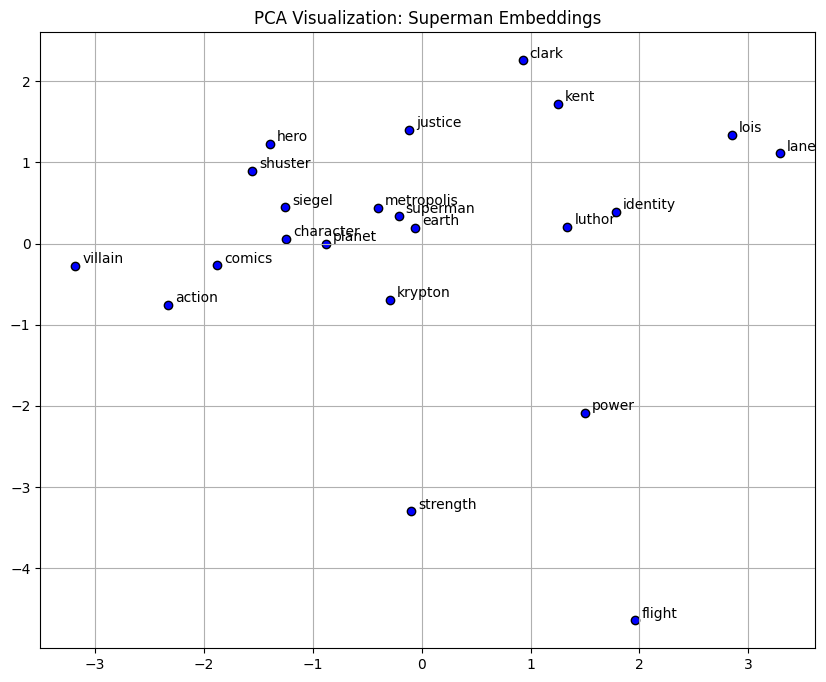

In [52]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def visualize_pca(model: Word2Vec):
    viz_words = [
        "superman", "clark", "kent", "metropolis", "lois", "lane",
        "krypton", "hero", "villain", "comics", "justice", "power",
        "earth", "planet", "character", "luthor", "identity",
        "strength", "flight", "action", "siegel", "shuster"
    ]
    valid_words = [w for w in viz_words if has_word(model, w)]
    vectors = np.array([model.wv[w] for w in valid_words])

    pca = PCA(n_components=2)
    coords = pca.fit_transform(vectors)

    plt.figure(figsize=(10, 8))
    plt.scatter(coords[:, 0], coords[:, 1], c='blue', edgecolors='k')
    for i, word in enumerate(valid_words):
        plt.annotate(word, xy=(coords[i, 0], coords[i, 1]), xytext=(5, 2), textcoords='offset points')
    plt.title("PCA Visualization: Superman Embeddings")
    plt.grid(True)
    plt.show()

visualize_pca(model_new)